# Coffea-Casa Benchmark Example
This example shows different split stategies implemented with coffea.dataset_tools for dataset and recomendation on how to write the code to get partial result of analysis in case some parts of fileset fail to complete analysis and produce result. 

In [1]:
import numpy as np
import histserv
%matplotlib inline
import hist
import coffea.processor as processor
import awkward as ak
from coffea.nanoevents import schemas
from coffea.dataset_tools import split_fileset, hash_fileset
from coffea.util import load, save

## Processor
*no changes or new practices needed on this stage

In [2]:
class Processor(processor.ProcessorABC):
    """
    Fills a remote histserv histogram instead of a local accumulator.
    The remote_hist is injected at construction time so the same
    server-side histogram is shared across all chunks/workers.
    """
    def __init__(self, remote_hist):
        self.h = remote_hist          # histserv RemoteHist
        self.cutflow = processor.defaultdict_accumulator(int)

    def process(self, events):
        dataset = events.metadata["dataset"]
        MET = events.MET.pt

        self.cutflow["all events"]    += len(MET)
        self.cutflow["number of chunks"] += 1

        # Fill directly on the server — no local accumulation needed
        self.h.fill(dataset=dataset, MET=MET)

        # Return only the lightweight cutflow; histogram lives on the server
        return {"cutflow": self.cutflow}

    def postprocess(self, accumulator):
        pass

In [3]:
# from dask.distributed import Client

# client = Client("tls://localhost:8786")

To collect partial result, the better practice would be to check whether the chunk(partial result of a subset of a fileset) was processed succesfully or not, instead of writing try-except python logic. If user wants the `processor.Runner` to return Result type output (as Ok(Accumulatable) if successfully processed or Err(Exception) if failed) than flag `use_result_type` in `processor.Runner` should be marked as `True`:

In [4]:
fileset = {'SingleMu_0':
           {"files":  {
               # broken link
                "root://eeeeeeospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/A41320F6-C9F9-574C-8DD2-BD98C200E4EE.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/A7FEFB1C-387F-2B4D-A111-C53CC9371EC7.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/AB10FBAB-92C0-C043-933D-117FCC5704BA.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/C6E8BB7F-7F54-0C4C-9EDF-479C7DBB12E4.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/CB90AA65-868A-F548-A291-3837A3113162.root": "Events",
                }
           },
           'SingleMu_1':
           {"files":  {
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/18B53494-657F-5744-8131-58ABA4EE00ED.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/2CCE1139-F301-C341-AE1E-4D27AF294018.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/300C603C-F1DD-4A40-B4DD-F4E0B239A460.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/39251543-EE21-9C4C-80D5-5D9178F55C71.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/3BD29D89-9C4A-E743-8616-C6806281BF12.root": "Events",
            }
           }
          }

# executor = processor.DaskExecutor(client=client)
executor = processor.FuturesExecutor()

address = "[::]:50051"
TOKEN = "MET-analysis"

hist_client = histserv.Client(address=address)
    
template = hist.Hist(
        hist.axis.StrCategory(name="dataset", label="", categories=list(fileset.keys()), growth=True),
        hist.axis.Regular(name="MET", label="MET [GeV]", bins=50, start=0, stop=100),
        storage=hist.storage.Weight(),
    )
remote_hist = hist_client.init(template, token=TOKEN)

run = processor.Runner(executor=executor,
                        schema=schemas.NanoAODSchema,
                        savemetrics=True,
                        use_result_type=True
                      )

import pprint

# one chunk (fileset subset) - one dataset -> 2 chunks
chunks_1 = split_fileset(fileset, strategy="by_dataset")
pprint.pprint(chunks_1)
print()
print(f"Chunks number: ", len(chunks_1))
print()
print("--------------------------------------------------------------------------------------")
print()
# one chunk - 20% of a certain dataset -> 10 chunks
chunks_2 = split_fileset(fileset, strategy="by_dataset", percentage=20)
pprint.pprint(chunks_2)
print()
print(f"Chunks number: ", len(chunks_2))
print()
print("--------------------------------------------------------------------------------------")
print()
# one chunk - combination of 20% of each dataset -> 5 chunks
chunks_3 = split_fileset(fileset, percentage=20)
pprint.pprint(chunks_3)
print()
print(f"Chunks number: ", len(chunks_3))

[{'SingleMu_0': {'files': {'root://eeeeeeospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/A41320F6-C9F9-574C-8DD2-BD98C200E4EE.root': 'Events',
                           'root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/A7FEFB1C-387F-2B4D-A111-C53CC9371EC7.root': 'Events',
                           'root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/AB10FBAB-92C0-C043-933D-117FCC5704BA.root': 'Events',
                           'root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_as

## Example: get partial result using Result type

In [5]:
cutflow = processor.defaultdict_accumulator(int)

In [6]:
for chunk in chunks_1:
    run_result = run(chunk, processor_instance=Processor(remote_hist))

    if run_result.is_ok():
        output, metrics = run_result.unwrap()
        cutflow += output["cutflow"]
    else:
        print("Error processing chunk, skipping...")
        continue

print("\nCutflow:", dict(cutflow))


hist_result = remote_hist.snapshot() 
print(hist_result)


Output()

/home/cms-jovyan/coffea/coffea/src/coffea/processor/executor.py:1171: UserWarning: Performed attempt 1 out of 4
  warnings.warn(


loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/site-packages/loky/process_executor.py", line 490, in _process_worker
    r = call_item()
        ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/loky/process_executor.py", line 291, in __call__
    return self.fn(*self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/cms-jovyan/coffea/coffea/src/coffea/processor/executor.py", line 1185, in automatic_retries
    raise e
  File "/home/cms-jovyan/coffea/coffea/src/coffea/processor/executor.py", line 1169, in automatic_retries
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/home/cms-jovyan/coffea/coffea/src/coffea/processor/executor.py", line 1239, in metadata_fetcher_root
    with uproot.open({item.filename: None}, timeout=xrootdtimeout) as file:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packa

Error processing chunk, skipping...


Output()

Output()


Cutflow: {'all events': 482000, 'number of chunks': 6}
ChunkedHist(
  StrCategory(..., growth=True, name='dataset'),
  Regular(50, 0, 100),
  storage=Weight()) # Chunks: 2, Bytes: 1.66 KB


/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())


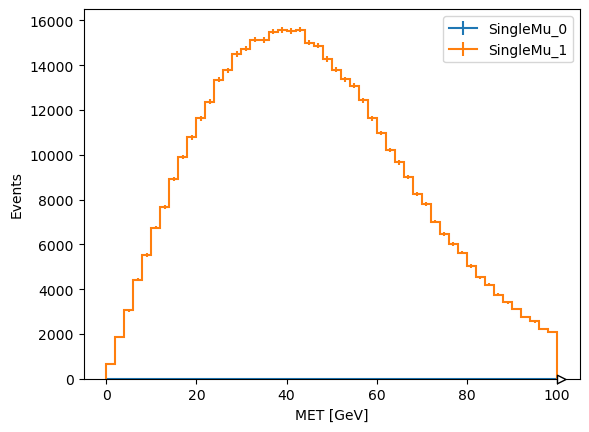

In [7]:
import matplotlib.pyplot as plt

hist_result = remote_hist.snapshot().to_hist()
fig, ax = plt.subplots()
for dataset in hist_result.axes[0]:
    hist_result[{"dataset": dataset}].plot1d(ax=ax, label=dataset)
ax.set_xlabel("MET [GeV]")
ax.set_ylabel("Events")
ax.legend()
plt.show()

In [8]:
# Easy way to print all cutflow dict values. Can just do print(output['cutflow']["KEY_NAME"]) for one.
for key, value in cutflow.items():
    print(key, value)

all events 482000
number of chunks 6


In [9]:
remote_hist.get_connection_info()

{'address': '[::]:50051',
 'hist_id': 'ae6615885fa34aebae02ce91148f6502',
 'token': 'MET-analysis'}

## Example: get partial result using Result type, different strategy

In [10]:
# strategy="by_dataset", percentage=20: each dataset is splitted separately by 100/20=5 chunks, * by 2 datasets (SingleMu_0, SingleMu_1) -> 10 chunks
# Expected result: merged result of 9 processed chunks
cutflow_2 = processor.defaultdict_accumulator(int)
remote_hist_2 = hist_client.init(template, token="graph_2")
print(remote_hist_2.get_connection_info())
for chunk in chunks_2:
    run_result = run(chunk, processor_instance=Processor(remote_hist_2))

    if run_result.is_ok():
        output, metrics = run_result.unwrap()
        cutflow_2 += output["cutflow"]
    else:
        print("Error processing chunk, skipping...")
        continue

print("\nCutflow:", dict(cutflow_2))


hist_result_2 = remote_hist_2.snapshot() 
print(hist_result_2)

{'address': '[::]:50051', 'hist_id': 'cbdb6cd435824e48b7e069dd5c68d43c', 'token': 'graph_2'}


Output()

Error processing chunk, skipping...


loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/site-packages/loky/process_executor.py", line 490, in _process_worker
    r = call_item()
        ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/loky/process_executor.py", line 291, in __call__
    return self.fn(*self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/cms-jovyan/coffea/coffea/src/coffea/processor/executor.py", line 1185, in automatic_retries
    raise e
  File "/home/cms-jovyan/coffea/coffea/src/coffea/processor/executor.py", line 1169, in automatic_retries
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/home/cms-jovyan/coffea/coffea/src/coffea/processor/executor.py", line 1239, in metadata_fetcher_root
    with uproot.open({item.filename: None}, timeout=xrootdtimeout) as file:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packa

Output()

...

Output()

Output()

Output()

Output()


Cutflow: {'all events': 1439000, 'number of chunks': 17}
ChunkedHist(
  StrCategory(..., growth=True, name='dataset'),
  Regular(50, 0, 100),
  storage=Weight()) # Chunks: 2, Bytes: 1.66 KB


In [11]:
hist_result_2

ChunkedHist(
  StrCategory(..., growth=True, name='dataset'),
  Regular(50, 0, 100),
  storage=Weight()) # Chunks: 2, Bytes: 1.66 KB

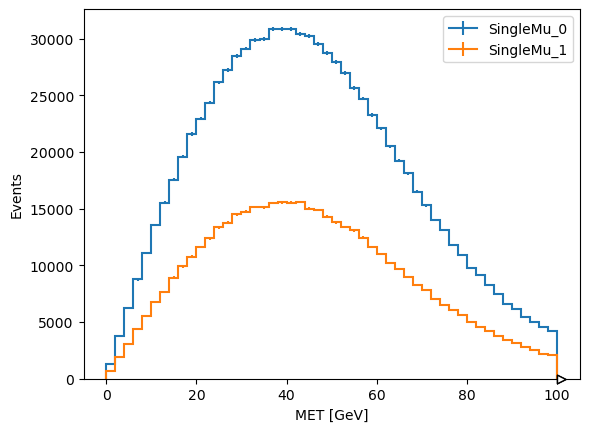

In [12]:
hist_result_2 = remote_hist_2.snapshot().to_hist()
fig, ax = plt.subplots()
for dataset in hist_result_2.axes[0]:
    hist_result_2[{"dataset": dataset}].plot1d(ax=ax, label=dataset)
ax.set_xlabel("MET [GeV]")
ax.set_ylabel("Events")
ax.legend()
plt.show()

In [13]:
for key, value in cutflow_2.items():
    print(key, value)

all events 1439000
number of chunks 17


## Example: get partial result, cache partial result to skip its running during the next attempt

In [17]:
import os

cutflow_3 = processor.defaultdict_accumulator(int)
remote_hist_3 = hist_client.init(template, token="graph_3")
print(remote_hist_3.get_connection_info())
cache_dir = "./chunk_cache"
os.makedirs(cache_dir, exist_ok=True)

{'address': '[::]:50051', 'hist_id': '415bed64cf524000a348b474f16fe539', 'token': 'graph_3'}


In [18]:
# percentage=20, 5 mixed chunks: 1st chunk is 20% of SingleMu_0 + 20% of SingleMu_1 ...
for chunk in chunks_3:
    chunk_hash = hash_fileset(chunk)
    cache_path = os.path.join(cache_dir, f"{chunk_hash}.coffea")

    if os.path.exists(cache_path):
        print(f"Loading cached result for chunk {chunk_hash}")
        output = load(cache_path)
    else:
        run_result = run(chunk, processor_instance=Processor(remote_hist_3))
        if run_result.is_ok():
            output, metrics = run_result.unwrap()
            save(output, cache_path)
            print(f"Saved result for chunk {chunk_hash}")
        else:
            # user can implement their own logic on how to treat failed chunks
            print(f"Error processing chunk...")
            continue
    cutflow_3 += output["cutflow"]
print("\nCutflow:", dict(cutflow_3))

hist_result_3 = remote_hist_3.snapshot() 
print(hist_result_3)


Output()

Error processing chunk...


loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/site-packages/loky/process_executor.py", line 490, in _process_worker
    r = call_item()
        ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/loky/process_executor.py", line 291, in __call__
    return self.fn(*self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/cms-jovyan/coffea/coffea/src/coffea/processor/executor.py", line 1185, in automatic_retries
    raise e
  File "/home/cms-jovyan/coffea/coffea/src/coffea/processor/executor.py", line 1169, in automatic_retries
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/home/cms-jovyan/coffea/coffea/src/coffea/processor/executor.py", line 1239, in metadata_fetcher_root
    with uproot.open({item.filename: None}, timeout=xrootdtimeout) as file:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packa

Output()

Saved result for chunk dc358fb840ee55eba00813becbcebadc7ed87f1ed6f1869ad8011efbc8217938


...

Saved result for chunk a65c4bf295a0cdf05e9936fc4778105111d10b0cda51d7d1a7f6050c4eedf366


Output()

Saved result for chunk 7df98284924bbe6600b8a31b3c44e4f43e76a6d4b4dd7dae26e1f54fffe1cd20


Output()

Saved result for chunk aeab620f36da8ac9fcfdf5bf319e8921f3bf8865874e5e28e88e2a48bde669bf

Cutflow: {'all events': 1292000, 'number of chunks': 16}
ChunkedHist(
  StrCategory(..., growth=True, name='dataset'),
  Regular(50, 0, 100),
  storage=Weight()) # Chunks: 2, Bytes: 1.66 KB


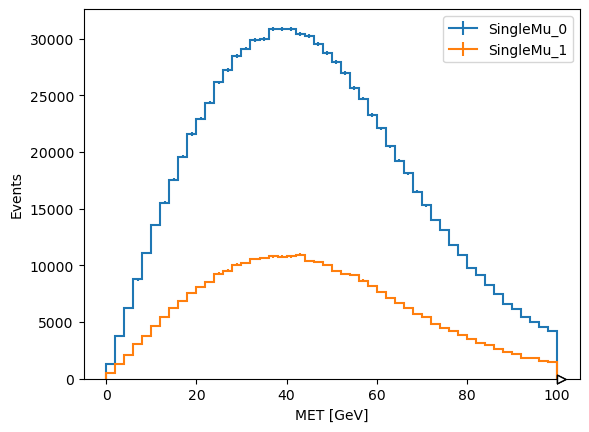

In [19]:
hist_result_3 = remote_hist_3.snapshot().to_hist()
fig, ax = plt.subplots()
for dataset in hist_result_3.axes[0]:
    hist_result_3[{"dataset": dataset}].plot1d(ax=ax, label=dataset)
ax.set_xlabel("MET [GeV]")
ax.set_ylabel("Events")
ax.legend()
plt.show()